
==================== CPI Event - Reversion Strategy (2Y) ====================
STRATEGY LOGIC:
1.  Identify Event Bias: Did Actual beat Surveyed?
2.  Entry: 09:00 AM (approx 30 mins after release).
3.  Direction: REVERSION (Fade the move).
    - If Yields spiked UP (Hot Data), we SHORT Yields.
    - If Yields dropped DOWN (Cool Data), we LONG Yields.
4.  Exit: End of Trading Day (16:00 PM).
--------------------------------------------------
PERFORMANCE METRICS:
Total Trades          18
Win Rate           55.6%
Avg Win           0.0383
Avg Loss          0.0303
Profit Factor       1.81
Max Drawdown     -0.0889
Total PnL         0.1713
Sharpe Ratio        0.20
--------------------------------------------------
TRADE LOG:
      Date  Signal     PnL
2023-07-12      -1  0.0841
2023-10-12       1 -0.0000
2023-11-14      -1 -0.0359
2023-12-12       1  0.0042
2024-01-11       1  0.1424
2024-02-13       1 -0.0550
2024-04-10       1 -0.0339
2024-06-12      -1  0.0546
2024-07-11      -1  0.0021
20

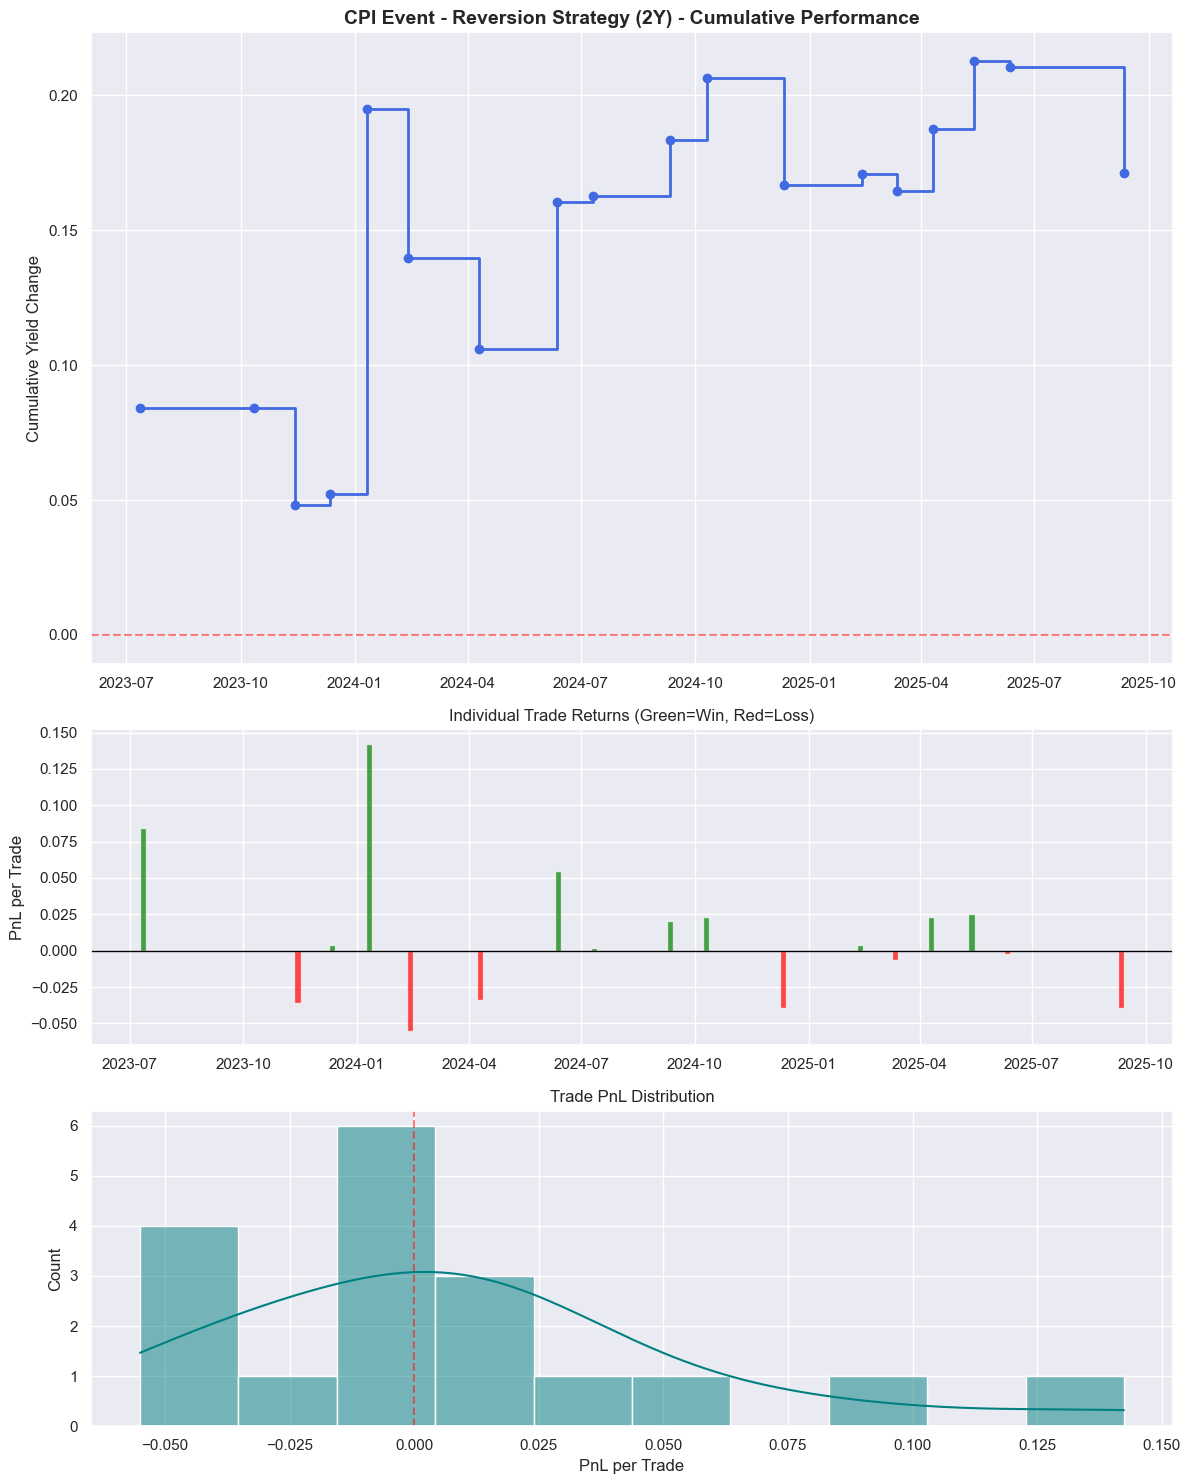


==================== Unemployment Event - Reversion Strategy (2Y) ====================
STRATEGY LOGIC:
1.  Identify Event Bias: Did Actual beat Surveyed?
2.  Entry: 09:00 AM (approx 30 mins after release).
3.  Direction: REVERSION (Fade the move).
    - If Yields spiked UP (Hot Data), we SHORT Yields.
    - If Yields dropped DOWN (Cool Data), we LONG Yields.
4.  Exit: End of Trading Day (16:00 PM).
--------------------------------------------------
PERFORMANCE METRICS:
Total Trades          19
Win Rate           52.6%
Avg Win           0.0585
Avg Loss          0.0481
Profit Factor       1.35
Max Drawdown     -0.2076
Total PnL         0.1519
Sharpe Ratio        0.13
--------------------------------------------------
TRADE LOG:
      Date  Signal     PnL
2023-08-04       1  0.1130
2023-09-01      -1  0.0958
2023-10-06      -1 -0.0379
2023-11-03      -1 -0.0376
2023-12-08       1 -0.0378
2024-01-05       1  0.0522
2024-02-02       1  0.0187
2024-03-08      -1  0.0334
2024-05-03      -1  

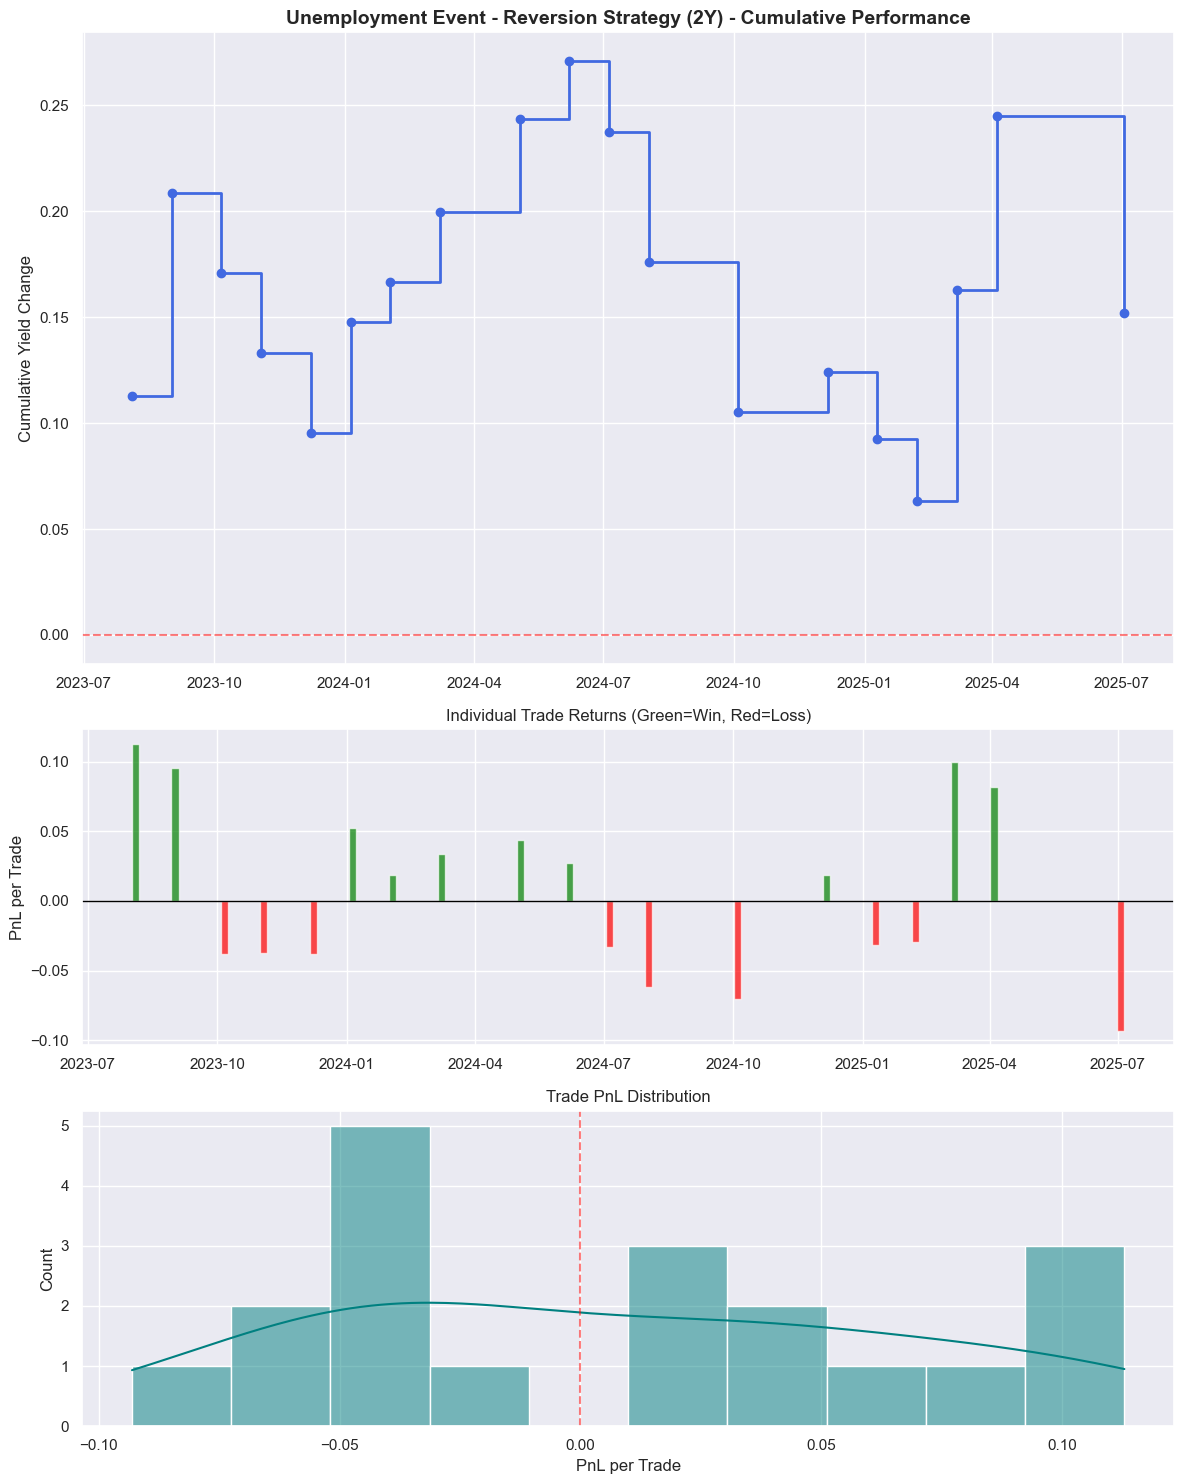

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (12, 6)

# ==========================================
# 1. Configuration & Data Loading
# ==========================================
# Load the datasets
cpi_df = pd.read_csv('cleaned_cpi_data.csv')
unemp_df = pd.read_csv('cleaned_unemployment_data.csv')

# Ensure Datetime columns are actually datetime objects
cpi_df['Datetime'] = pd.to_datetime(cpi_df['Datetime'])
unemp_df['Datetime'] = pd.to_datetime(unemp_df['Datetime'])

# ==========================================
# 2. The Strategy Engine
# ==========================================
def run_intraday_strategy(df, event_name, entry_time='09:00:00'):
    """
    Backtests a simple intraday strategy:
    1. Determine Fundamental Bias (Did data beat/miss expectations?)
    2. Enter at specific time (e.g., 9:00 AM)
    3. Exit at End of Day
    """
    
    # Extract just the time component for filtering
    df = df.copy() # Avoid SettingWithCopyWarning
    df['Time_Component'] = df['Datetime'].dt.time
    unique_dates = df['Date'].unique()
    
    trades = []
    
    for date in unique_dates:
        # Get data for this specific day
        day_data = df[df['Date'] == date].sort_values('Datetime')
        
        if day_data.empty:
            continue
            
        # --- A. Determine the News Signal ---
        actual = day_data['Actual'].iloc[0]
        surveyed = day_data['Surveyed'].iloc[0]
        
        # 1 = Bullish Yields (Rates Up), -1 = Bearish Yields (Rates Down)
        fundamental_bias = 0
        
        if event_name == 'CPI':
            if actual > surveyed:
                fundamental_bias = 1  # Inflation Hot -> Yields Up
            elif actual < surveyed:
                fundamental_bias = -1 # Inflation Cool -> Yields Down
                
        elif event_name == 'Unemployment':
            if actual > surveyed:
                fundamental_bias = -1 # Bad Econ Data -> Yields Down (Flight to Safety)
            elif actual < surveyed:
                fundamental_bias = 1  # Strong Econ -> Yields Up
        
        # If data came in exactly as expected, no trade
        if fundamental_bias == 0:
            continue

        # --- B. Execute Trade ---
        # Entry: First price at or after target entry time
        entry_threshold = pd.to_datetime(entry_time).time()
        entry_candidates = day_data[day_data['Time_Component'] >= entry_threshold]
        
        if entry_candidates.empty:
            continue
            
        entry_row = entry_candidates.iloc[0]
        exit_row = day_data.iloc[-1] # Exit at last available print of the day
        
        # --- C. Calculate Results ---
        # Price change in Yields (Exit - Entry)
        raw_pnl_2y = exit_row['2Y_Yield'] - entry_row['2Y_Yield']
        raw_pnl_10y = exit_row['10Y_Yield'] - entry_row['10Y_Yield']
        
        # Strategy 1: TREND (Follow the news)
        trend_pnl_2y = fundamental_bias * raw_pnl_2y
        trend_pnl_10y = fundamental_bias * raw_pnl_10y
        
        # Strategy 2: REVERSION (Fade the news)
        reversion_pnl_2y = -trend_pnl_2y
        reversion_pnl_10y = -trend_pnl_10y

        trades.append({
            'Date': date,
            'Signal': fundamental_bias,
            'Entry_Time': entry_row['Time'],
            'Exit_Time': exit_row['Time'],
            'Trend_PnL_2Y': trend_pnl_2y,
            'Trend_PnL_10Y': trend_pnl_10y,
            'Reversion_PnL_2Y': reversion_pnl_2y,
            'Reversion_PnL_10Y': reversion_pnl_10y
        })
        
    return pd.DataFrame(trades)

# ==========================================
# 3. Visualization & Metrics
# ==========================================
def display_performance(trade_df, pnl_col, title):
    if trade_df.empty:
        print(f"No Trades for {title}")
        return
    
    # --- FIX: SORT BY DATE CHRONOLOGICALLY ---
    # Convert to datetime and sort Oldest -> Newest
    trade_df['Date'] = pd.to_datetime(trade_df['Date'])
    trade_df = trade_df.sort_values('Date', ascending=True).reset_index(drop=True)
    # -----------------------------------------
    
    # --- Strategy Description ---
    print(f"\n{'='*20} {title} {'='*20}")
    print("STRATEGY LOGIC:")
    print("1.  Identify Event Bias: Did Actual beat Surveyed?")
    print("2.  Entry: 09:00 AM (approx 30 mins after release).")
    print("3.  Direction: REVERSION (Fade the move).")
    print("    - If Yields spiked UP (Hot Data), we SHORT Yields.")
    print("    - If Yields dropped DOWN (Cool Data), we LONG Yields.")
    print("4.  Exit: End of Trading Day (16:00 PM).")
    print("-" * 50)

    # --- Metrics ---
    pnl = trade_df[pnl_col]
    wins = pnl[pnl > 0]
    losses = pnl[pnl < 0]
    
    # Calculate Max Drawdown
    cumulative = pnl.cumsum()
    peak = cumulative.cummax()
    drawdown = cumulative - peak
    max_drawdown = drawdown.min()
    
    metrics = {
        'Total Trades': len(pnl),
        'Win Rate': f"{len(wins) / len(pnl):.1%}",
        'Avg Win': f"{wins.mean():.4f}" if not wins.empty else "0",
        'Avg Loss': f"{abs(losses.mean()):.4f}" if not losses.empty else "0",
        'Profit Factor': f"{wins.sum() / abs(losses.sum()):.2f}" if not losses.empty else "Inf",
        'Max Drawdown': f"{max_drawdown:.4f}",
        'Total PnL': f"{pnl.sum():.4f}",
        'Sharpe Ratio': f"{pnl.mean() / pnl.std():.2f}" if pnl.std() != 0 else "0"
    }
    
    print("PERFORMANCE METRICS:")
    print(pd.Series(metrics).to_string())
    print("-" * 50)
    
    # --- Trade Log ---
    print("TRADE LOG:")
    # Format the dataframe for display
    display_df = trade_df.copy()
    display_df['PnL'] = display_df[pnl_col].apply(lambda x: f"{x:.4f}")
    if 'Surprise' in display_df.columns:
        display_df['Surprise'] = display_df['Surprise'].apply(lambda x: f"{x:.3f}")
    
    # Select relevant columns
    cols_to_show = ['Date', 'Signal', 'PnL']
    if 'Surprise' in display_df.columns:
        cols_to_show.insert(1, 'Surprise')
        
    print(display_df[cols_to_show].to_string(index=False))
    
    # --- Visualization ---
    fig, axes = plt.subplots(3, 1, figsize=(12, 15), gridspec_kw={'height_ratios': [2, 1, 1]})
    
    # 1. Cumulative PnL Curve (Step Plot)
    trade_df['Cumulative_PnL'] = trade_df[pnl_col].cumsum()
    # trade_df['Date'] is already datetime from the fix above
    
    # Use a step plot to show that PnL is flat between trades
    axes[0].step(trade_df['Date'], trade_df['Cumulative_PnL'], where='post', marker='o', linewidth=2, color='royalblue')
    axes[0].axhline(0, color='red', linestyle='--', alpha=0.5)
    axes[0].set_title(f'{title} - Cumulative Performance', fontsize=14, fontweight='bold')
    axes[0].set_ylabel('Cumulative Yield Change')
    
    # 2. Individual Trade Returns (Bar Chart)
    colors = ['green' if x > 0 else 'red' for x in trade_df[pnl_col]]
    # Increase bar width to make them visible on the timeline (width=5 days)
    axes[1].bar(trade_df['Date'], trade_df[pnl_col], color=colors, alpha=0.7, width=5)
    axes[1].axhline(0, color='black', linewidth=1)
    axes[1].set_title('Individual Trade Returns (Green=Win, Red=Loss)', fontsize=12)
    axes[1].set_ylabel('PnL per Trade')
    
    # 3. Trade Distribution (Histogram)
    sns.histplot(data=trade_df, x=pnl_col, kde=True, ax=axes[2], color='teal', bins=10)
    axes[2].axvline(0, color='red', linestyle='--', alpha=0.5)
    axes[2].set_title('Trade PnL Distribution', fontsize=12)
    axes[2].set_xlabel('PnL per Trade')
    
    plt.tight_layout()
    plt.show()

# ==========================================
# 4. Run Execution
# ==========================================

# Run backtests
cpi_results = run_intraday_strategy(cpi_df, 'CPI')
unemp_results = run_intraday_strategy(unemp_df, 'Unemployment')

# Display Results for Reversion Strategy on 2Y Yield
display_performance(cpi_results, 'Reversion_PnL_2Y', 'CPI Event - Reversion Strategy (2Y)')
display_performance(unemp_results, 'Reversion_PnL_2Y', 'Unemployment Event - Reversion Strategy (2Y)')

# 5. Optimization: Filtering for Significant Surprises
As identified in our analysis, the strategy suffers from "fat tails" and a lack of consistency in recent months. A potential fix is to filter for **significant surprises only**.

The hypothesis is that small deviations (e.g., 0.1%) are often noise or already priced in, leading to choppy price action. By trading only when the surprise is larger, we might capture the true "repricing" events.

Below, we implement a `run_filtered_strategy` that takes a `threshold` parameter.
- **CPI Threshold:** We will test `0.001` (0.1%) and `0.002` (0.2%).
- **Unemployment Threshold:** We will test `0.001` (0.1%) and `0.002` (0.2%).


   CPI STRATEGY OPTIMIZATION

==================== CPI - All Trades (No Filter) ====================
Total Trades        18
Win Rate         55.6%
Avg Win         0.0383
Avg Loss        0.0303
Total PnL       0.1713
Sharpe Ratio      0.20


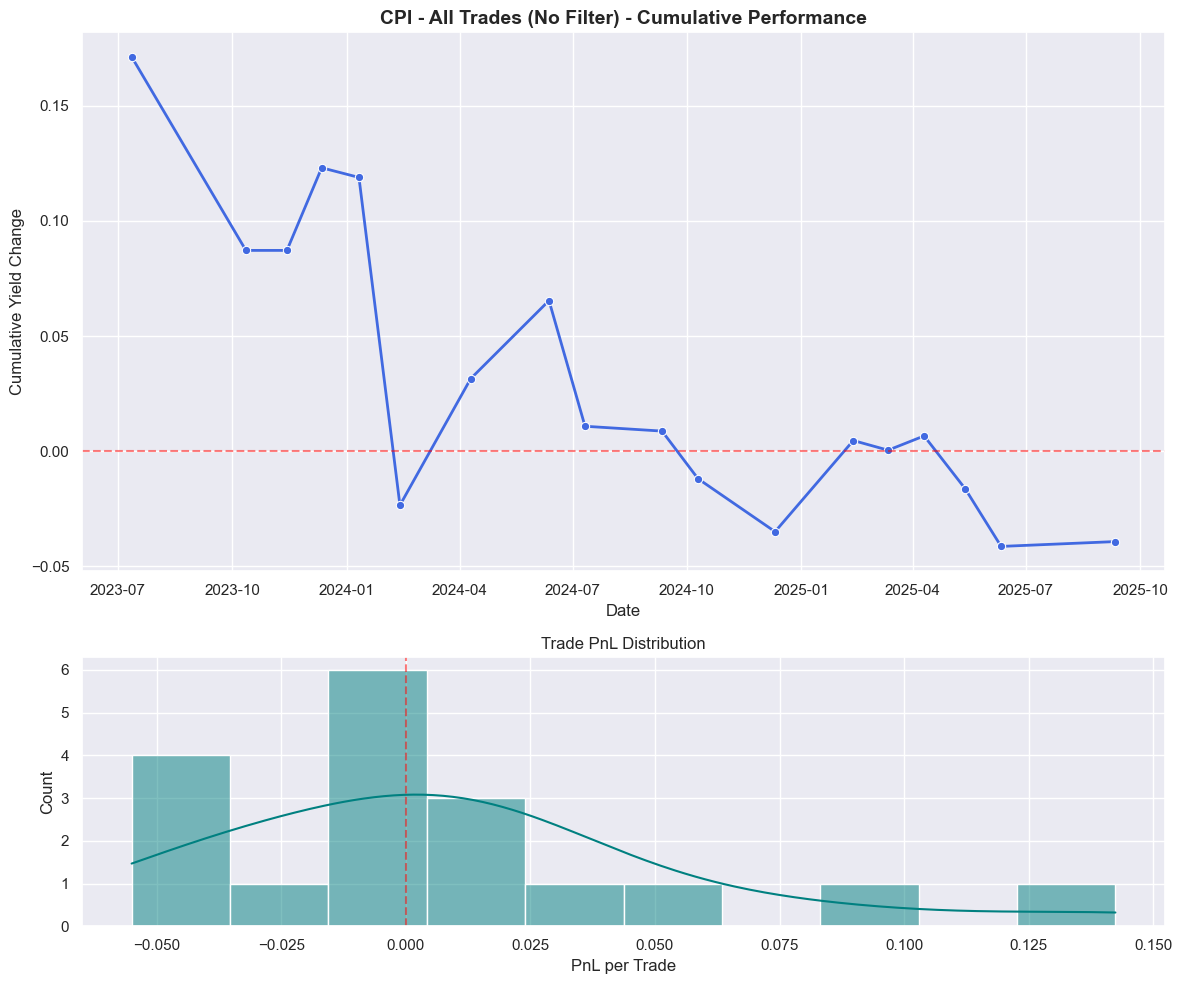


==================== CPI - Filtered (>= 0.1% Surprise) ====================
Total Trades        16
Win Rate         56.2%
Avg Win         0.0403
Avg Loss        0.0287
Total PnL       0.1902
Sharpe Ratio      0.24


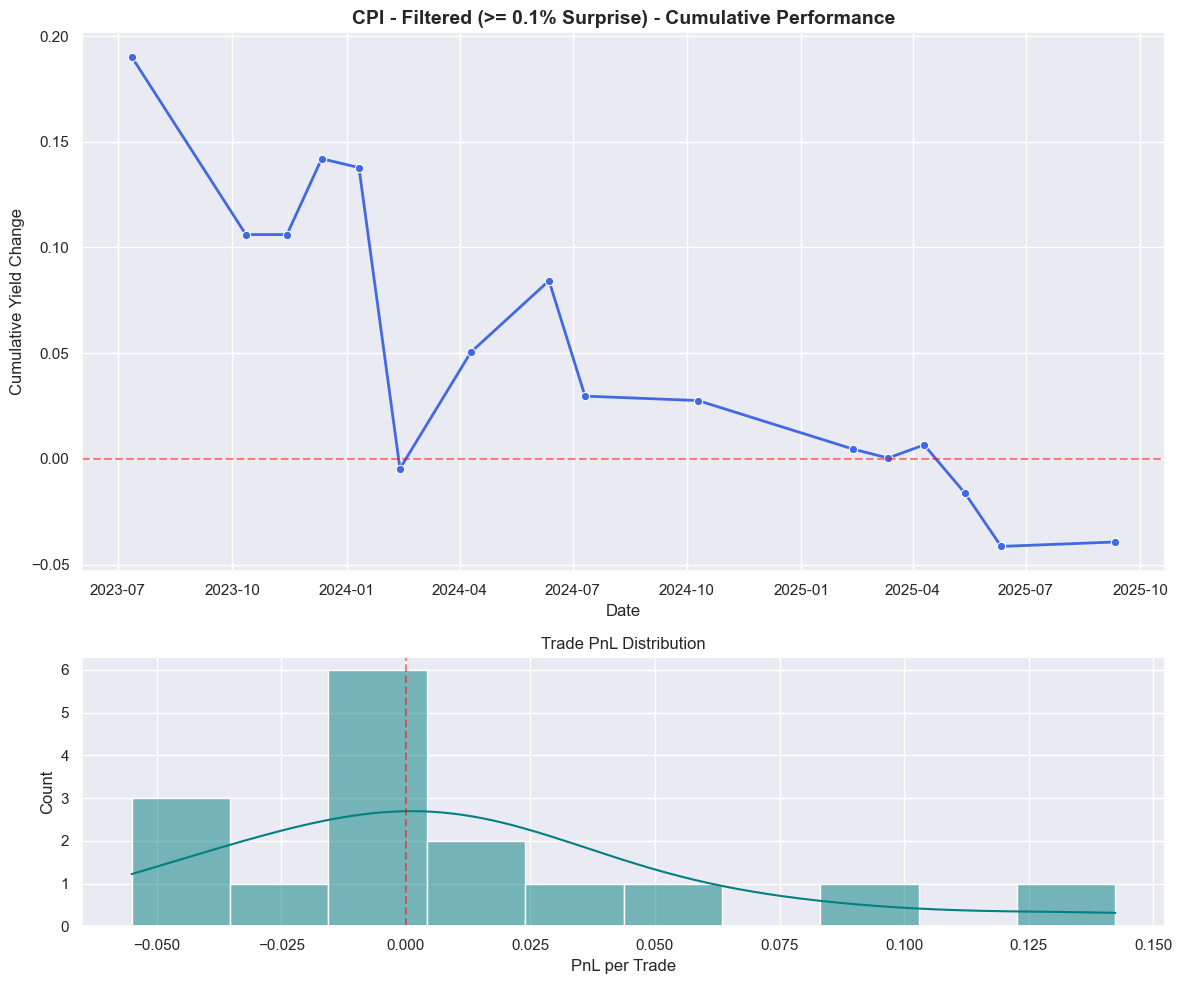


==================== CPI - High Conviction (>= 0.2% Surprise) ====================
Total Trades         3
Win Rate        100.0%
Avg Win         0.0097
Avg Loss             0
Total PnL       0.0292
Sharpe Ratio      0.85


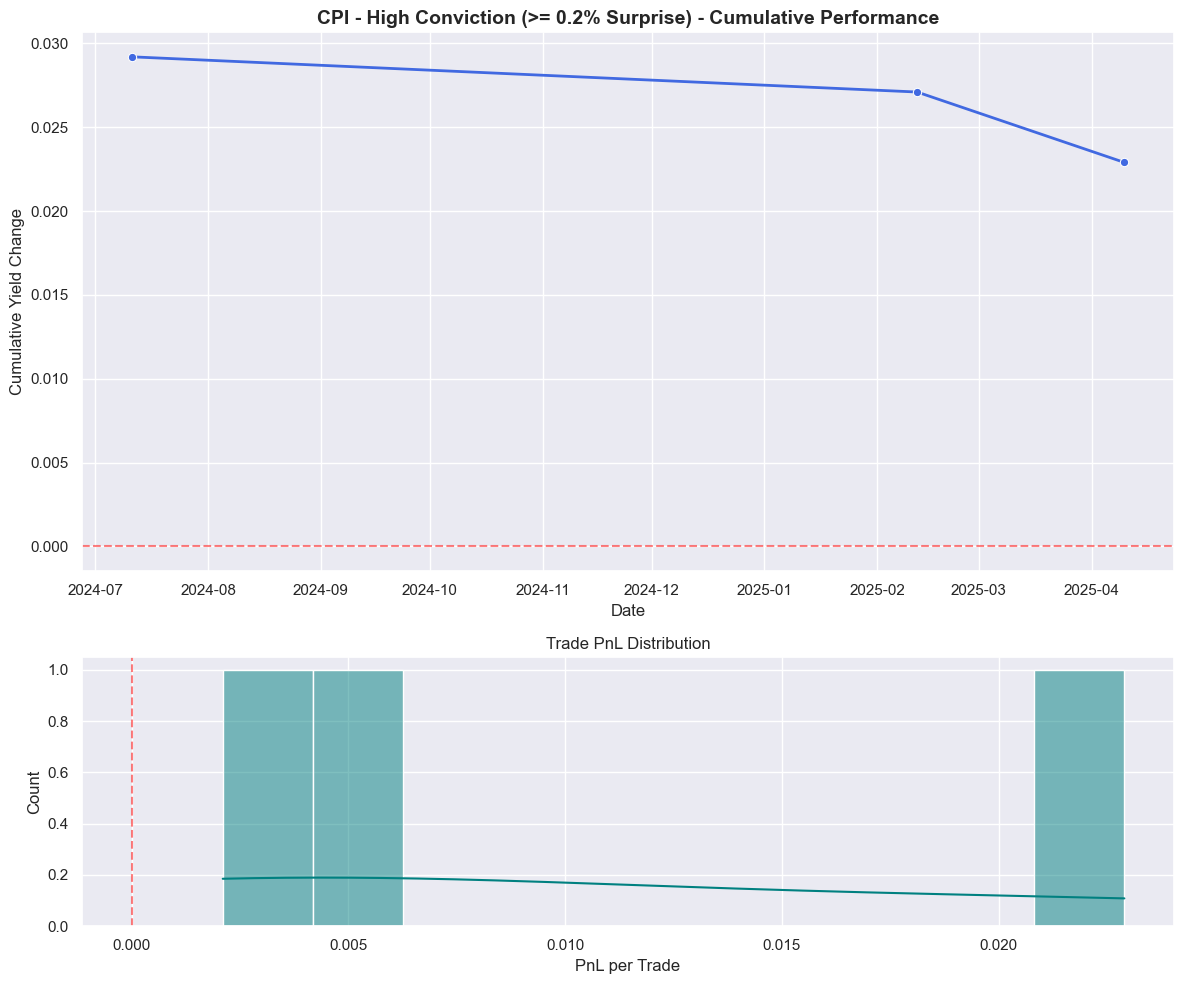


   UNEMPLOYMENT STRATEGY OPTIMIZATION

==================== Unemployment - All Trades ====================
Total Trades        19
Win Rate         52.6%
Avg Win         0.0585
Avg Loss        0.0481
Total PnL       0.1519
Sharpe Ratio      0.13


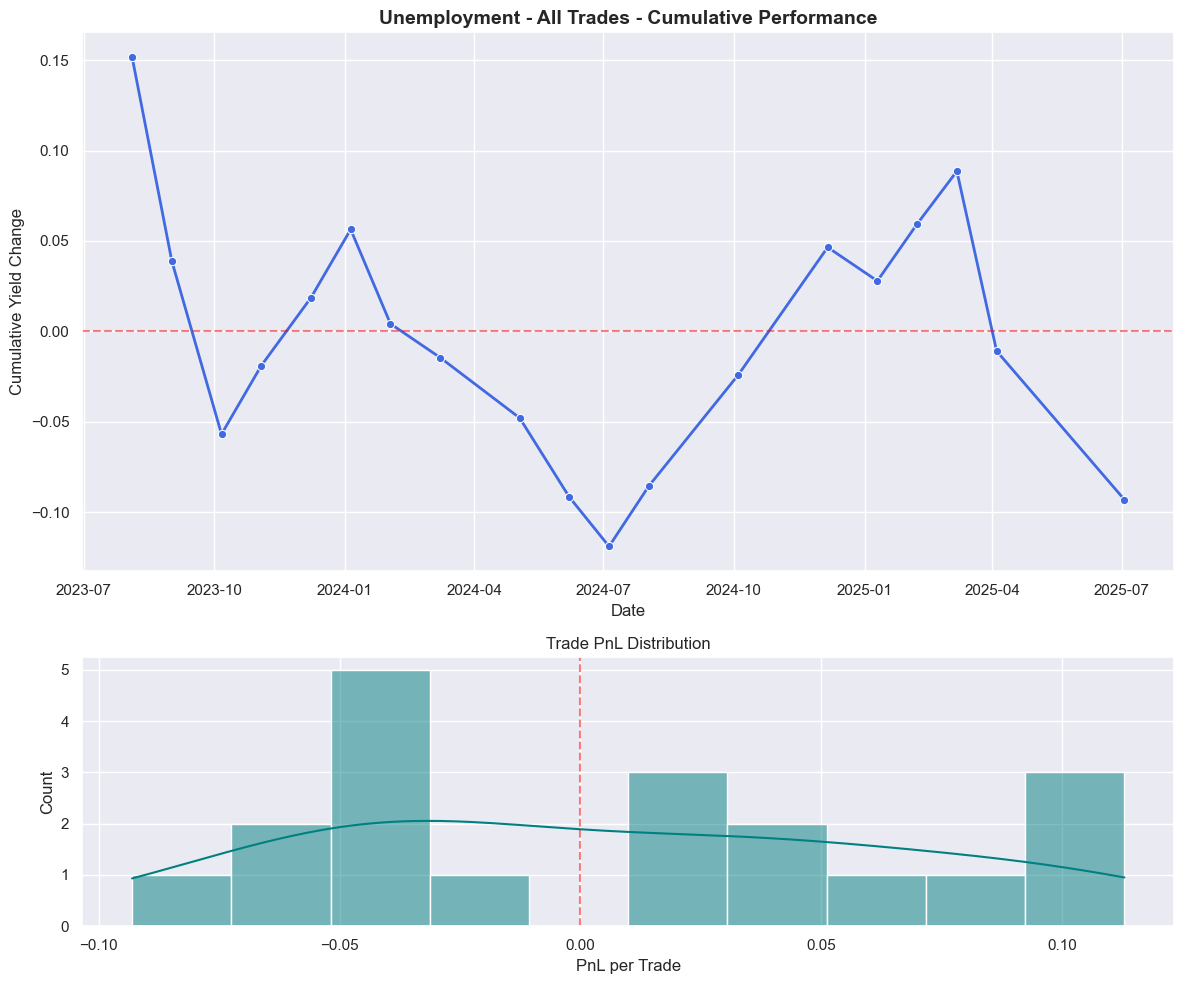


==================== Unemployment - Filtered (>= 0.1% Surprise) ====================
Total Trades        17
Win Rate         47.1%
Avg Win         0.0566
Avg Loss        0.0481
Total PnL       0.0203
Sharpe Ratio      0.02


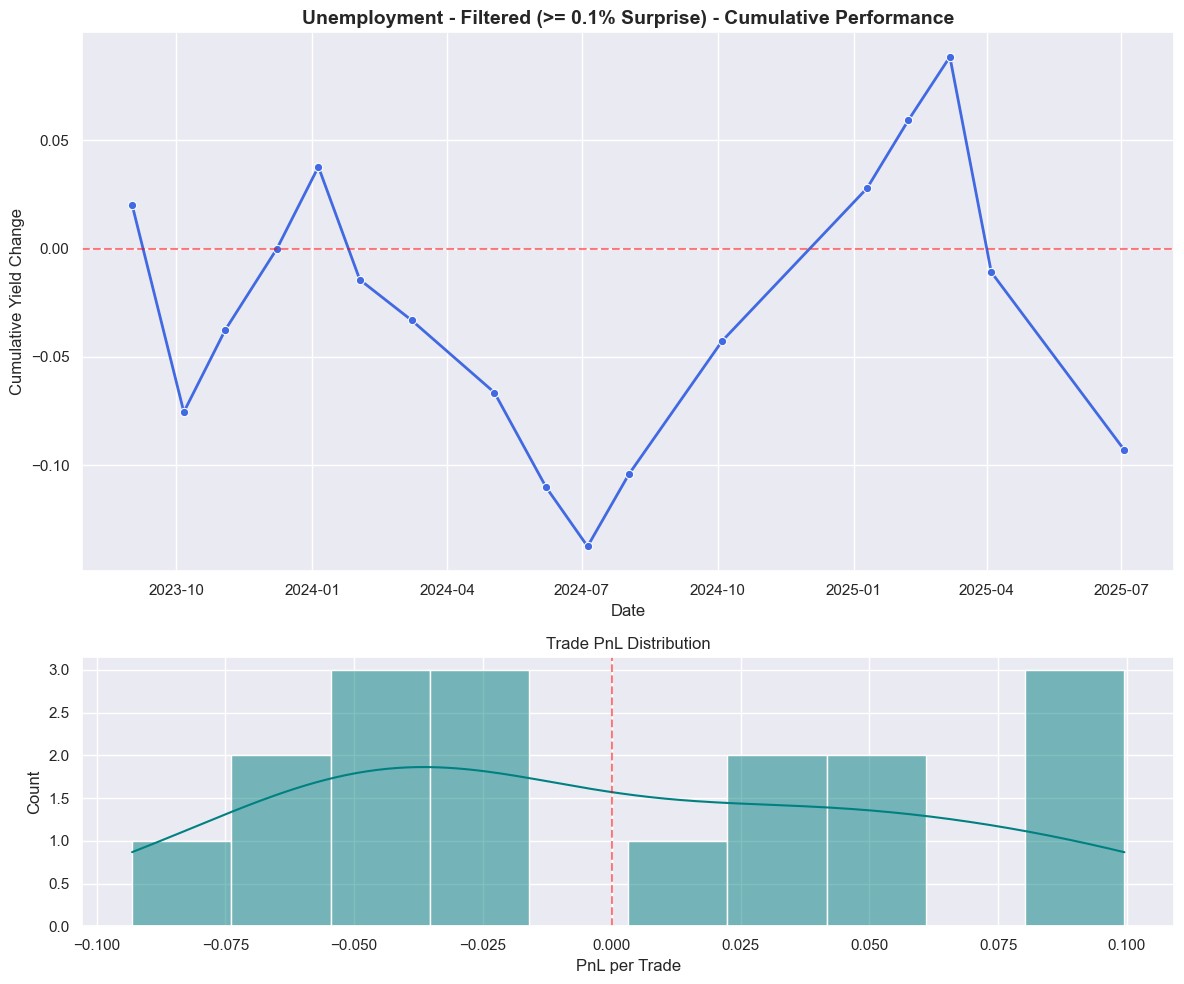

In [3]:
def run_filtered_strategy(df, event_name, threshold=0.0, entry_time='09:00:00'):
    """
    Runs the intraday strategy but only takes trades when:
    abs(Actual - Surveyed) >= threshold
    """
    
    # Extract just the time component for filtering
    df = df.copy()
    df['Time_Component'] = df['Datetime'].dt.time
    unique_dates = df['Date'].unique()
    
    trades = []
    
    for date in unique_dates:
        # Get data for this specific day
        day_data = df[df['Date'] == date].sort_values('Datetime')
        
        if day_data.empty:
            continue
            
        # --- A. Determine the News Signal ---
        actual = day_data['Actual'].iloc[0]
        surveyed = day_data['Surveyed'].iloc[0]
        
        surprise_magnitude = abs(actual - surveyed)
        
        # FILTER: Skip if the surprise is too small
        if surprise_magnitude < threshold:
            continue
        
        # 1 = Bullish Yields (Rates Up), -1 = Bearish Yields (Rates Down)
        fundamental_bias = 0
        
        if event_name == 'CPI':
            if actual > surveyed:
                fundamental_bias = 1  # Inflation Hot -> Yields Up
            elif actual < surveyed:
                fundamental_bias = -1 # Inflation Cool -> Yields Down
                
        elif event_name == 'Unemployment':
            if actual > surveyed:
                fundamental_bias = -1 # Bad Econ Data -> Yields Down (Flight to Safety)
            elif actual < surveyed:
                fundamental_bias = 1  # Strong Econ -> Yields Up
        
        if fundamental_bias == 0:
            continue

        # --- B. Execute Trade ---
        entry_threshold = pd.to_datetime(entry_time).time()
        entry_candidates = day_data[day_data['Time_Component'] >= entry_threshold]
        
        if entry_candidates.empty:
            continue
            
        entry_row = entry_candidates.iloc[0]
        exit_row = day_data.iloc[-1]
        
        # --- C. Calculate Results ---
        raw_pnl_2y = exit_row['2Y_Yield'] - entry_row['2Y_Yield']
        
        # Reversion Strategy PnL
        reversion_pnl_2y = -1 * fundamental_bias * raw_pnl_2y

        trades.append({
            'Date': date,
            'Signal': fundamental_bias,
            'Surprise': surprise_magnitude,
            'Reversion_PnL_2Y': reversion_pnl_2y
        })
        
    return pd.DataFrame(trades)

# --- Run Comparisons ---

# 1. CPI Analysis
print("\n" + "="*30)
print("   CPI STRATEGY OPTIMIZATION")
print("="*30)

# Threshold 0.0 (Original)
cpi_all = run_filtered_strategy(cpi_df, 'CPI', threshold=0.0)
display_performance(cpi_all, 'Reversion_PnL_2Y', 'CPI - All Trades (No Filter)')

# Threshold 0.001 (>= 0.1% Surprise)
cpi_filter_1 = run_filtered_strategy(cpi_df, 'CPI', threshold=0.001)
display_performance(cpi_filter_1, 'Reversion_PnL_2Y', 'CPI - Filtered (>= 0.1% Surprise)')

# Threshold 0.002 (>= 0.2% Surprise)
cpi_filter_2 = run_filtered_strategy(cpi_df, 'CPI', threshold=0.002)
display_performance(cpi_filter_2, 'Reversion_PnL_2Y', 'CPI - High Conviction (>= 0.2% Surprise)')


# 2. Unemployment Analysis
print("\n" + "="*30)
print("   UNEMPLOYMENT STRATEGY OPTIMIZATION")
print("="*30)

# Threshold 0.0 (Original)
unemp_all = run_filtered_strategy(unemp_df, 'Unemployment', threshold=0.0)
display_performance(unemp_all, 'Reversion_PnL_2Y', 'Unemployment - All Trades')

# Threshold 0.001 (>= 0.1% Surprise)
unemp_filter_1 = run_filtered_strategy(unemp_df, 'Unemployment', threshold=0.001)
display_performance(unemp_filter_1, 'Reversion_PnL_2Y', 'Unemployment - Filtered (>= 0.1% Surprise)')